<a href="https://colab.research.google.com/github/PENGxiaun/Demand-Forecasting-and-Inventory-Logistics-Optimization-for-Turkish-Retail-Supply-Chain/blob/main/Complete%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapter0 Data cleaning**

In [4]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [5]:
# 1. Download the dataset
path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")
csv_filename = "ecommerce_customer_behavior_dataset.csv"
full_path = os.path.join(path, csv_filename)

Using Colab cache for faster access to the 'e-commerce-customer-behavior-and-sales-analysis-tr' dataset.


In [6]:
# 2. Read the CSV file
df = pd.read_csv(full_path)

In [7]:
# 3. Basic data cleaning
df = df.drop_duplicates()
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=object).columns
# Fill missing values in numerical columns with the mean
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [8]:
# 4. Outlier detection function using IQR
def detect_outliers(df, columns):
    outliers_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_info[col] = {
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outliers_count": len(outliers),
            "outliers_index": outliers.index.tolist(),
            "outliers_data": outliers[col].values
        }
    return outliers_info


In [9]:
# 5. Run outlier detection
outliers_result = detect_outliers(df, num_cols)

In [10]:
# 6. Print outlier statistics
for col, info in outliers_result.items():
    print(f"{col}: {info['outliers_count']} extreme values")

    # Show some example extreme values
    if info['outliers_count'] > 0:
        print(f"Example extreme values in {col}: {info['outliers_data'][:5]}")

Age: 30 extreme values
Example extreme values in Age: [66 65 73 71 75]
Unit_Price: 513 extreme values
Example extreme values in Unit_Price: [2107.37 1784.75 1837.61 4136.98 1375.1 ]
Quantity: 0 extreme values
Discount_Amount: 879 extreme values
Example extreme values in Discount_Amount: [229.28  62.15 490.25 100.24 156.33]
Total_Amount: 546 extreme values
Example extreme values in Total_Amount: [3778.05 4214.74 6648.75 4485.1  3518.89]
Session_Duration_Minutes: 124 extreme values
Example extreme values in Session_Duration_Minutes: [48 36 38 52 36]
Pages_Viewed: 14 extreme values
Example extreme values in Pages_Viewed: [20 19 19 18 18]
Delivery_Time_Days: 141 extreme values
Example extreme values in Delivery_Time_Days: [17 17 15 16 16]
Customer_Rating: 0 extreme values


/tmp/ipykernel_1412/2881582797.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, labels=num_cols, patch_artist=True)


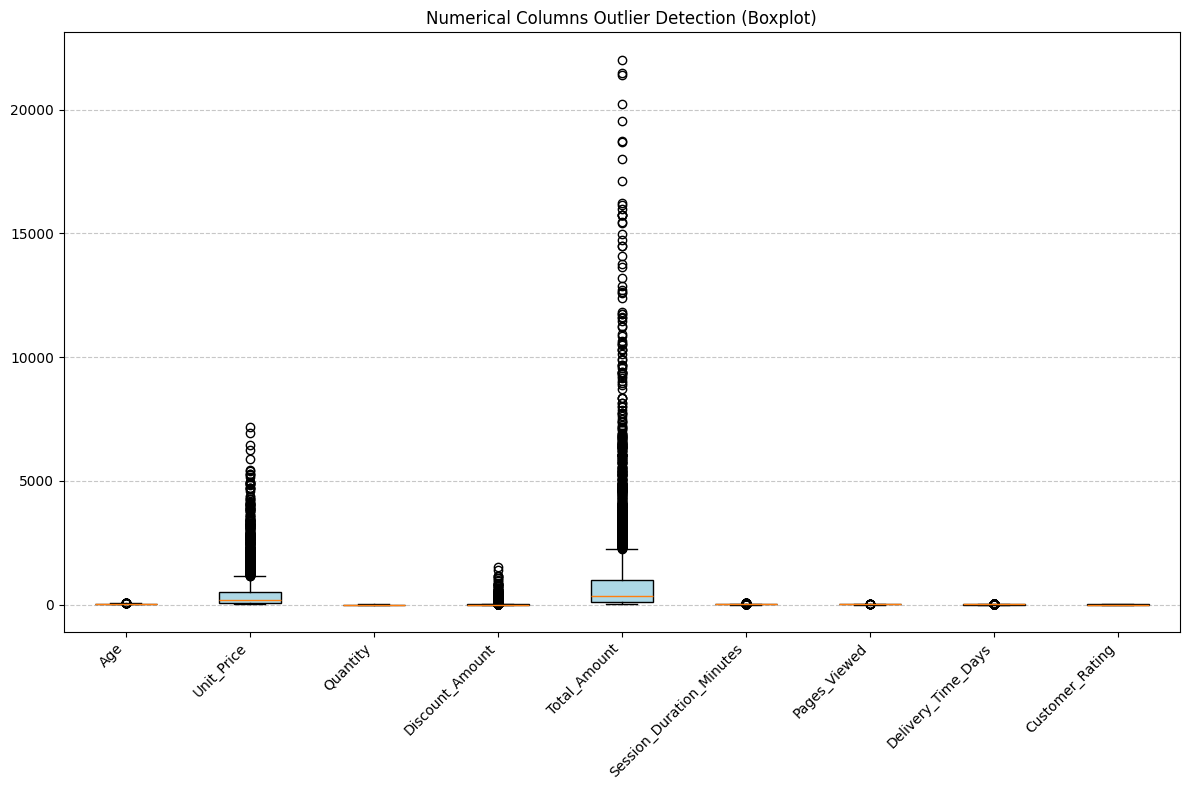

In [11]:
# 8. Boxplot visualization for numerical columns
plt.figure(figsize=(12,8))
plot_data = [df[col].values for col in num_cols]
box = plt.boxplot(plot_data, labels=num_cols, patch_artist=True)
for patch in box['boxes']:
    patch.set_facecolor('lightblue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Numerical Columns Outlier Detection (Boxplot)")
plt.tight_layout()
plt.show()

In [12]:
# 9. Save the cleaned dataset to CSV and download
cleaned_csv_path = "/content/sales_data_clean.csv"
df.to_csv(cleaned_csv_path, index=False)
files.download(cleaned_csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Chapter1 Demand Forecasting**

In [15]:
###Supply_Chain_Demand_Forecasting_Prophet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
from prophet.plot import plot_plotly, plot_components_plotly
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [16]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

Saving sales_data_clean.csv to sales_data_clean (1).csv


In [19]:
# Upload widget is only available when the cell has been executed in the current browser session. Please rerun this cell to enable.

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [21]:
# 2. Set Visualization Style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [22]:
# 3. Load and Preprocess Data
df = pd.read_csv('sales_data_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
# 4. Basic Data Aggregation
category_analysis = df.groupby('Product_Category').agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum'
}).sort_values(by='Total_Amount', ascending=False)

category_analysis['AOV'] = category_analysis['Total_Amount'] / category_analysis['Quantity']
category_analysis['Sales_Percent'] = (category_analysis['Total_Amount'] / category_analysis['Total_Amount'].sum()) * 100

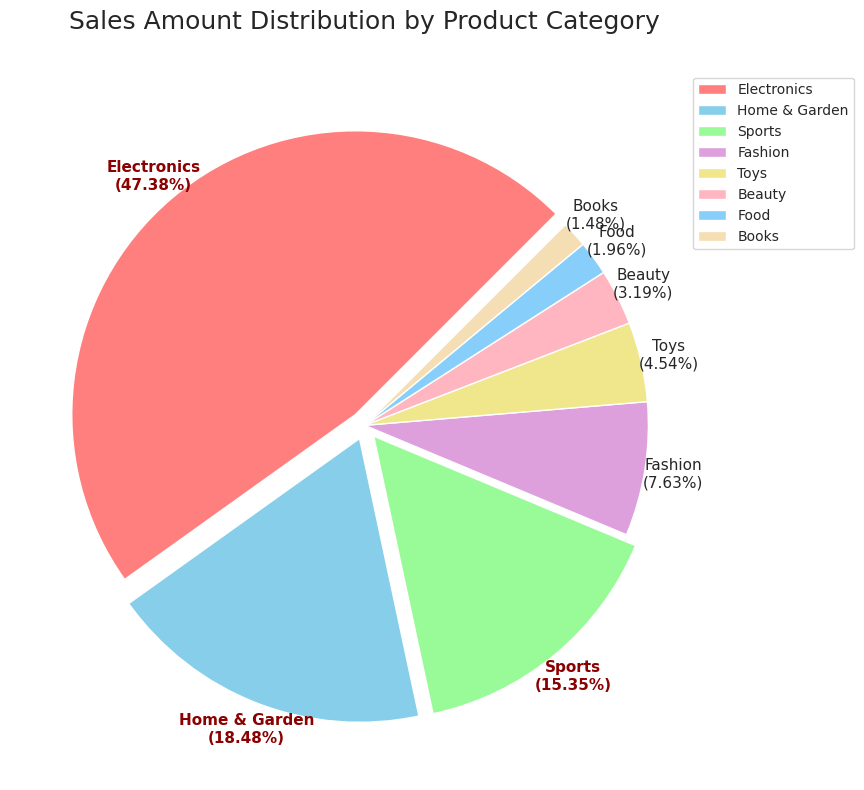

In [24]:
# Descriptive Analytics - Core Charts
# ---------- Chart 1: Sales Amount Distribution Pie Chart ----------
plt.figure(figsize=(12, 8))
colors = ['#FF7F7F', '#87CEEB', '#98FB98', '#DDA0DD', '#F0E68C', '#FFB6C1', '#87CEFA', '#F5DEB3']
sales_percent = category_analysis['Sales_Percent'].round(2)
labels = [f'{cat}\n({pct}%)' for cat, pct in zip(category_analysis.index, sales_percent)]
explode = [0.05 if p > 10 else 0 for p in sales_percent]

patches, texts, autotexts = plt.pie(
    sales_percent,
    labels=labels,
    autopct='',
    explode=explode,
    colors=colors,
    startangle=45,
    textprops={'fontsize': 11, 'ha': 'center'},
    labeldistance=1.1
)

for i, text in enumerate(texts):
    if sales_percent.iloc[i] > 10:
        text.set_fontweight('bold')
        text.set_color('darkred')

plt.title('Sales Amount Distribution by Product Category', fontsize=18, pad=30)
plt.tight_layout()
plt.legend(patches, category_analysis.index, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.savefig('sales_amount_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

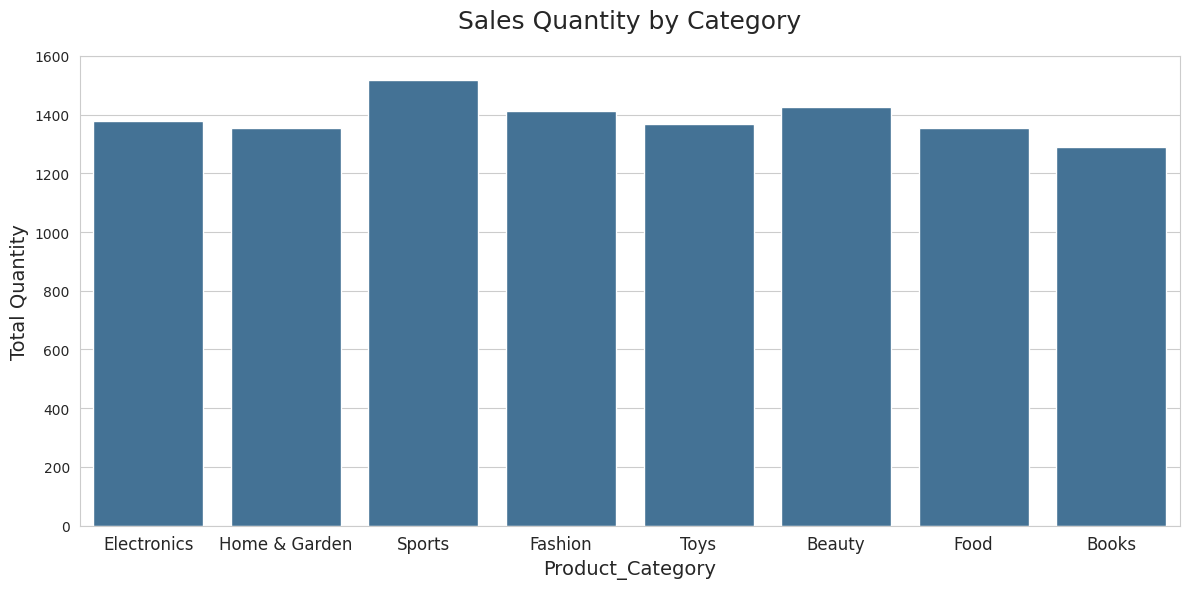

In [25]:
# ---------- Chart 2: Sales Quantity by Category ----------
plt.figure(figsize=(12, 6))
category_order = ['Electronics', 'Home & Garden', 'Sports', 'Fashion', 'Toys', 'Beauty', 'Food', 'Books']
quantity_values = [category_analysis.loc[cat, 'Quantity'] for cat in category_order]

ax2 = sns.barplot(x=category_order, y=quantity_values, color='#3674A3')
plt.title('Sales Quantity by Category', fontsize=18, pad=20)
plt.ylabel('Total Quantity', fontsize=14)
plt.xlabel('Product_Category', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylim(0, 1600)
plt.tight_layout()
plt.savefig('sales_quantity_by_category.png', dpi=300, bbox_inches='tight')
plt.show()


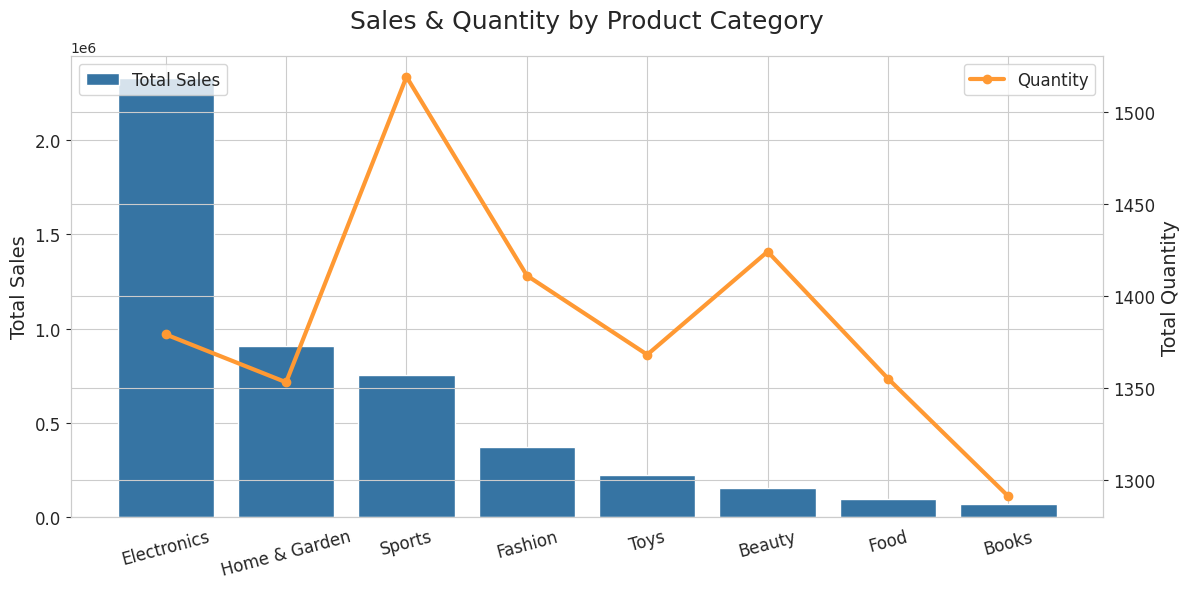

In [26]:
# ---------- Chart 3: Sales & Quantity Dual-Axis Chart ----------
category_sum = df.groupby('Product_Category').agg(
    Total_Amount=('Total_Amount', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()
category_sum = category_sum.set_index('Product_Category').loc[category_order].reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(category_sum['Product_Category'], category_sum['Total_Amount'], color='#3674A3', label='Total Sales')
ax1.set_ylabel('Total Sales', fontsize=14)
ax1.tick_params(axis='x', rotation=15, labelsize=12)
ax1.tick_params(axis='y', labelsize=12)

ax2 = ax1.twinx()
ax2.plot(category_sum['Product_Category'], category_sum['Quantity'], color='#FF9933', marker='o', linewidth=3, label='Quantity')
ax2.set_ylabel('Total Quantity', fontsize=14)
ax2.tick_params(axis='y', labelsize=12)

plt.title('Sales & Quantity by Product Category', fontsize=18, pad=20)
ax1.legend(loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig('sales_quantity_dual_axis.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# Part 2: Full Category Prophet Forecasting
# Fixed category order (consistent with charts)
category_order = ['Electronics', 'Home & Garden', 'Sports', 'Fashion', 'Toys', 'Beauty', 'Food', 'Books']

# Store forecasts and evaluation results
forecast_dict = {}
eval_results = {}

for cat in category_order:
    print(f"Processing {cat} Category...")
    # Filter and aggregate data for current category
    cat_data = df[df['Product_Category'] == cat].copy()
    cat_ts = cat_data.groupby('Date')['Quantity'].sum().reset_index()
    cat_ts.columns = ['ds', 'y']  # Rename to Prophet's required format

    # Initialize and train Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.fit(cat_ts)

    # Generate 90-day forecast
    future = model.make_future_dataframe(periods=90)
    forecast = model.predict(future)

    # Calculate model performance metrics (on historical data only)
    y_true = cat_ts['y'].values
    y_pred = forecast.iloc[:len(y_true)]['yhat'].values
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Save results
    forecast_dict[cat] = forecast
    eval_results[cat] = {'RMSE': round(rmse, 2), 'R²': round(r2, 2)}

    # Save individual category forecast to CSV
    forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    forecast_output.to_csv(f'{cat}_90day_forecast.csv', index=False)

Processing Electronics Category...
Processing Home & Garden Category...
Processing Sports Category...
Processing Fashion Category...
Processing Toys Category...
Processing Beauty Category...
Processing Food Category...
Processing Books Category...


In [28]:
# Fixed category order (consistent with charts)
category_order = ['Electronics', 'Home & Garden', 'Sports', 'Fashion', 'Toys', 'Beauty', 'Food', 'Books']

# Store forecasts and evaluation results
forecast_dict = {}
eval_results = {}

for cat in category_order:
    print(f"Processing {cat} Category...")
    # Filter and aggregate data for current category
    cat_data = df[df['Product_Category'] == cat].copy()
    cat_ts = cat_data.groupby('Date')['Quantity'].sum().reset_index()
    cat_ts.columns = ['ds', 'y']  # Rename to Prophet's required format

    # Initialize and train Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.fit(cat_ts)

    # Generate 90-day forecast
    future = model.make_future_dataframe(periods=90)
    forecast = model.predict(future)

    # Calculate model performance metrics (on historical data only)
    y_true = cat_ts['y'].values
    y_pred = forecast.iloc[:len(y_true)]['yhat'].values
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Save results
    forecast_dict[cat] = forecast
    eval_results[cat] = {'RMSE': round(rmse, 2), 'R²': round(r2, 2)}

    # Save individual category forecast to CSV
    forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    forecast_output.to_csv(f'{cat}_90day_forecast.csv', index=False)

Processing Electronics Category...
Processing Home & Garden Category...
Processing Sports Category...
Processing Fashion Category...
Processing Toys Category...
Processing Beauty Category...
Processing Food Category...
Processing Books Category...


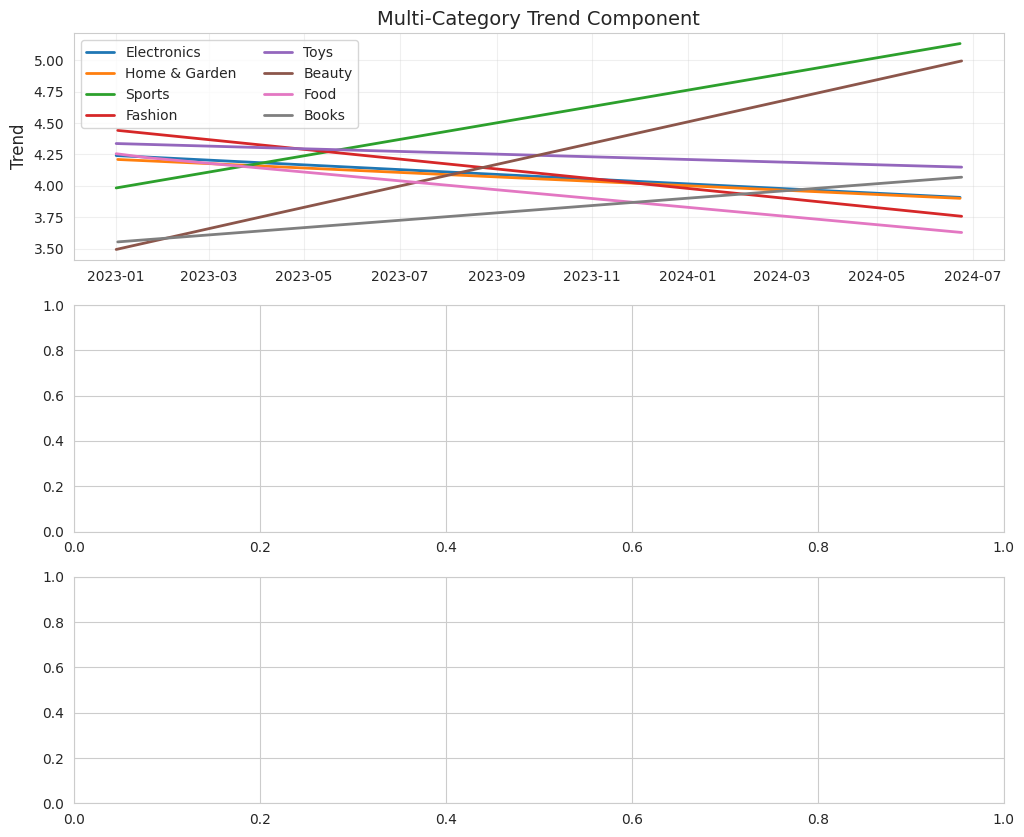

In [29]:
# Chart 4: Multi-Category Seasonal Components (Trend + Weekly + Yearly)
# ==============================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
colors = sns.color_palette("tab10", n_colors=8)

# Subplot 1: Trend Component
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat]
    ax1.plot(fc['ds'], fc['trend'], label=cat, color=colors[i], linewidth=2)
ax1.set_title('Multi-Category Trend Component', fontsize=14)
ax1.set_ylabel('Trend', fontsize=12)
ax1.legend(ncol=2, fontsize=10)
ax1.grid(alpha=0.3)

In [30]:
# Subplot 2: Weekly Seasonality Component
# Prophet's weekly component is fixed. We need to derive day_of_week from 'ds' for plotting.
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat].copy() # Use a copy to avoid SettingWithCopyWarning if modifying in place
    # Calculate day of week, adjusting so Sunday is 0 to align with desired x-axis labels
    fc['day_of_week_plot'] = (fc['ds'].dt.dayofweek + 1) % 7 # Sunday=0, Monday=1, ..., Saturday=6

    # Extract unique weekly component for each day of the week and sort by day_of_week_plot
    weekly_component_data = fc[['day_of_week_plot', 'weekly']].drop_duplicates(subset=['day_of_week_plot']).sort_values('day_of_week_plot')

    ax2.plot(weekly_component_data['day_of_week_plot'], weekly_component_data['weekly'], label=cat, color=colors[i], linewidth=2)
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # These labels now correctly align with day_of_week_plot
ax2.set_title('Multi-Category Weekly Seasonality', fontsize=14)
ax2.set_ylabel('Weekly', fontsize=12)
ax2.grid(alpha=0.3)

In [31]:
# Subplot 3: Yearly Seasonality Component
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat]
    yearly = fc[fc['ds'].dt.year == 2023][['yearly', 'ds']].copy()
    yearly['dayofyear'] = yearly['ds'].dt.dayofyear
    ax3.plot(yearly['dayofyear'], yearly['yearly'], label=cat, color=colors[i], linewidth=2)
ax3.set_title('Multi-Category Yearly Seasonality', fontsize=14)
ax3.set_ylabel('Yearly', fontsize=12)
ax3.set_xlabel('Day of Year', fontsize=12)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('multi_category_seasonal_components.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

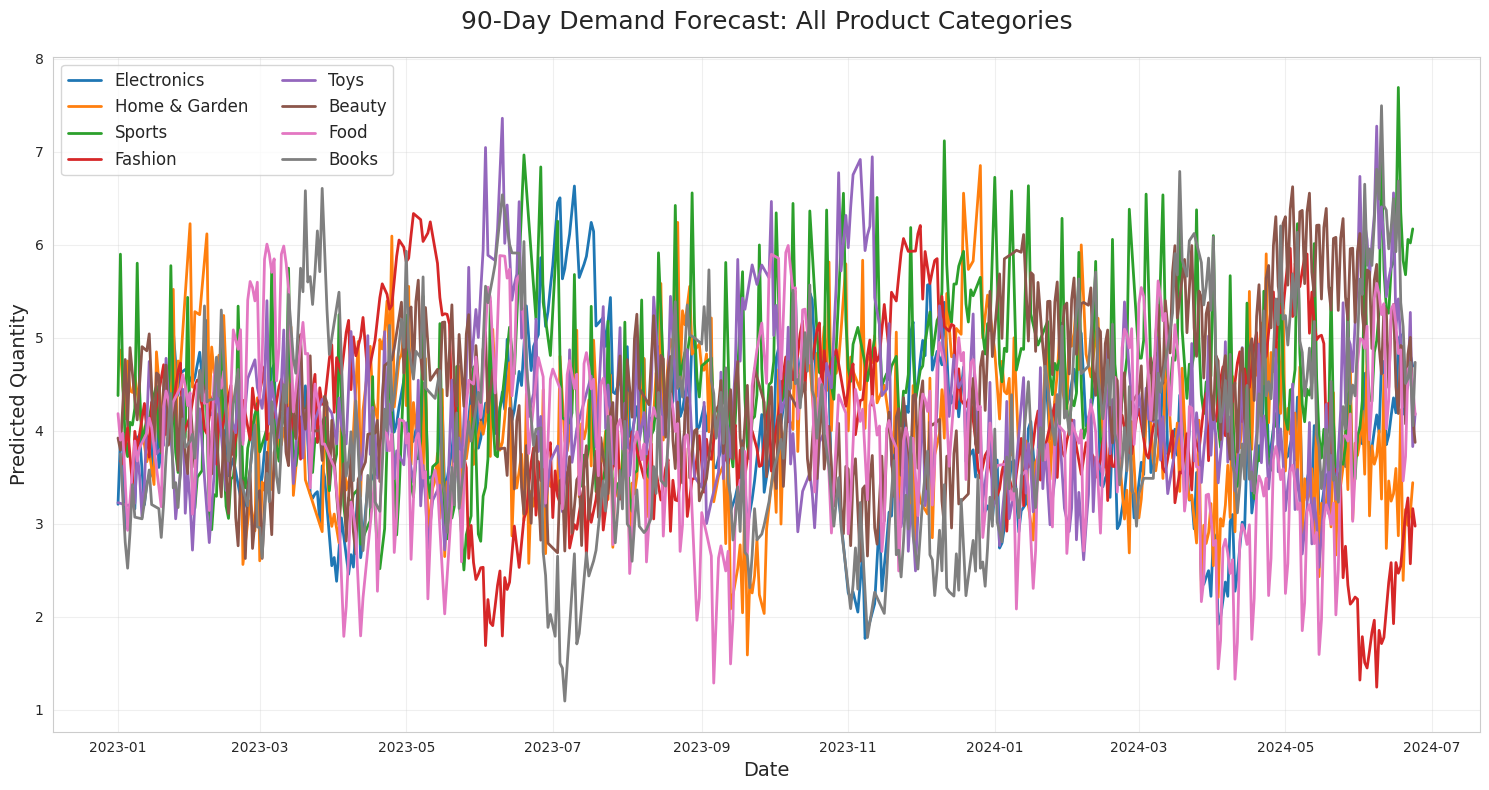

In [32]:
# Chart 5: Multi-Category 90-Day Demand Forecast
# ==============================================
plt.figure(figsize=(15, 8))
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat]
    plt.plot(fc['ds'], fc['yhat'], label=cat, color=colors[i], linewidth=2)
    # Optional: Add confidence interval
    # plt.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], color=colors[i], alpha=0.1)

plt.title('90-Day Demand Forecast: All Product Categories', fontsize=18, pad=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Predicted Quantity', fontsize=14)
plt.legend(ncol=2, fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multi_category_90day_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Export All Summary CSV Files + Download Function
# ==============================================
# 1. Save category analysis summary
category_analysis.to_csv('category_analysis_summary.csv', index=True)

# 2. Save model evaluation results
eval_df = pd.DataFrame(eval_results).T
eval_df.to_csv('prophet_model_evaluation.csv', index=True)

# 3. Download function (support both Colab and local environment)
try:
    # For Google Colab
    from google.colab import files
    # Download all CSV files
    files.download('category_analysis_summary.csv')
    files.download('prophet_model_evaluation.csv')
    # Download individual category forecast CSV
    for cat in category_order:
        files.download(f'{cat}_90day_forecast.csv')
    print("\n✅ All CSV files downloaded successfully (Colab Environment)")
except ImportError:
    # For local environment (files saved to current working directory)
    print("\n✅ All CSV files saved to your current working directory (Local Environment)")
    print("📂 Files list:")
    print("   - category_analysis_summary.csv (Basic category metrics)")
    print("   - prophet_model_evaluation.csv (RMSE/R² for all categories)")
    print("   - [Category Name]_90day_forecast.csv (Individual category forecast)")




Processing Electronics Category...
Processing Home & Garden Category...
Processing Sports Category...
Processing Fashion Category...
Processing Toys Category...
Processing Beauty Category...
Processing Food Category...
Processing Books Category...
============================================================
Prophet Model Performance Evaluation - Electronics Category
============================================================
RMSE: 2.84
R²: 0.08
============================================================
============================================================
Prophet Model Performance Evaluation - Home & Garden Category
============================================================
RMSE: 2.9
R²: 0.08
============================================================
============================================================
Prophet Model Performance Evaluation - Sports Category
============================================================
RMSE: 3.05
R²: 0.08
============================================================
============================================================
Prophet Model Performance Evaluation - Fashion Category
============================================================
RMSE: 2.67
R²: 0.1
============================================================
============================================================
Prophet Model Performance Evaluation - Toys Category
============================================================
RMSE: 3.02
R²: 0.08
============================================================
============================================================
Prophet Model Performance Evaluation - Beauty Category
============================================================
RMSE: 2.71
R²: 0.07
============================================================
============================================================
Prophet Model Performance Evaluation - Food Category
============================================================
RMSE: 2.8
R²: 0.1
============================================================
============================================================
Prophet Model Performance Evaluation - Books Category
============================================================
RMSE: 2.68
R²: 0.14
============================================================


✅ All CSV files downloaded successfully (Colab Environment)

# **Chapter2 Inventory Logistics**

✅ Data loaded successfully!


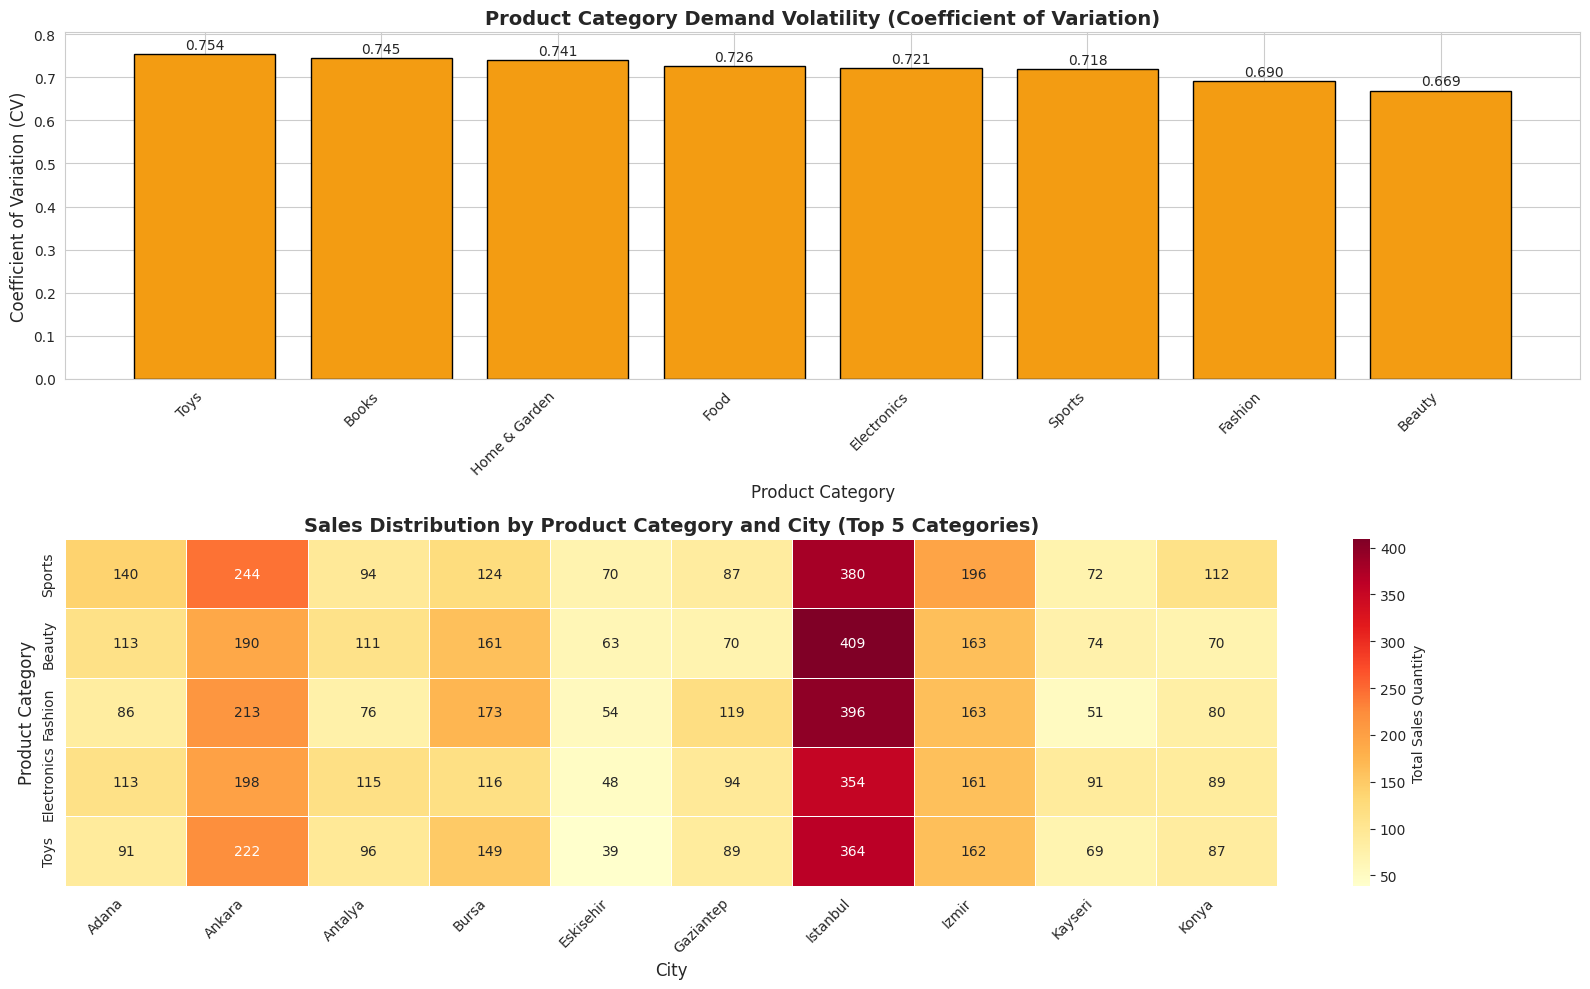


--- Task 2.1.1: Demand Volatility Analysis (CV) ---


,Product_Category,CV,Risk_Level
7,Toys,0.754386,Medium Risk (Volatile)
1,Books,0.745318,Medium Risk (Volatile)
5,Home & Garden,0.740623,Medium Risk (Volatile)
4,Food,0.725506,Medium Risk (Volatile)
2,Electronics,0.720999,Medium Risk (Volatile)
6,Sports,0.718458,Medium Risk (Volatile)
3,Fashion,0.690414,Medium Risk (Volatile)
0,Beauty,0.669139,Medium Risk (Volatile)



--- Task 2.1.2: Sales Distribution by Category and City (Top 5 Cities Display) ---


City,Adana,Ankara,Antalya,Bursa,Eskisehir,Gaziantep,Istanbul,Izmir,Kayseri,Konya
Product_Category,,,,,,,,,,
Beauty,113,190,111,161,63,70,409,163,74,70
Books,112,163,104,140,63,105,358,128,53,65
Electronics,113,198,115,116,48,94,354,161,91,89
Fashion,86,213,76,173,54,119,396,163,51,80
Food,53,227,99,143,65,117,328,167,67,89


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and font (optimized for English display)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.figure(figsize=(16, 10))

# 1. Load Dataset
try:
    # Note: Update path to your actual file location (root directory)
    df = pd.read_csv('sales_data_clean.csv')
    print("✅ Data loaded successfully!")

    # 2. Calculate Demand Volatility (Coefficient of Variation - CV)
    daily_sales = df.groupby(['Product_Category', 'Date'])['Quantity'].sum().reset_index()
    stats = daily_sales.groupby('Product_Category')['Quantity'].agg(['mean', 'std']).reset_index()
    stats['CV'] = stats['std'] / stats['mean']

    # Classify risk levels based on CV values
    def classify_risk(cv):
        if cv < 0.5: return 'Low Risk (Stable)'
        if cv < 1.0: return 'Medium Risk (Volatile)'
        return 'High Risk (Unstable)'
    stats['Risk_Level'] = stats['CV'].apply(classify_risk)

    # ========== Visualization 1: Demand Volatility Bar Chart (Sorted by CV Descending) ==========
    plt.subplot(2, 1, 1)  # 2 rows, 1 column - first subplot
    # Sort by CV in descending order
    stats_sorted = stats.sort_values(by='CV', ascending=False)
    # Define risk level color mapping
    color_map = {'Low Risk (Stable)': '#2ecc71', 'Medium Risk (Volatile)': '#f39c12', 'High Risk (Unstable)': '#e74c3c'}
    colors = [color_map[r] for r in stats_sorted['Risk_Level']]

    # Plot bar chart
    bars = plt.bar(stats_sorted['Product_Category'], stats_sorted['CV'], color=colors, edgecolor='black')
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    plt.title('Product Category Demand Volatility (Coefficient of Variation)', fontsize=14, fontweight='bold')
    plt.xlabel('Product Category', fontsize=12)
    plt.ylabel('Coefficient of Variation (CV)', fontsize=12)
    plt.ylim(0, max(stats['CV']) + 0.05)  # Adjust y-axis range for better label visibility
    plt.xticks(rotation=45, ha='right')  # Rotate category labels to avoid overlap

    # ========== Visualization 2: Geographic Sales Distribution Heatmap (Top 5 Categories) ==========
    plt.subplot(2, 1, 2)  # 2 rows, 1 column - second subplot
    # Calculate sales distribution by category and city
    city_dist = df.groupby(['Product_Category', 'City'])['Quantity'].sum().unstack().fillna(0)
    top5_categories = city_dist.sum(axis=1).nlargest(5).index  # Top 5 categories by total sales
    city_dist_top5 = city_dist.loc[top5_categories]

    # Plot heatmap
    sns.heatmap(city_dist_top5, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'Total Sales Quantity'})
    plt.title('Sales Distribution by Product Category and City (Top 5 Categories)', fontsize=14, fontweight='bold')
    plt.xlabel('City', fontsize=12)
    plt.ylabel('Product Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Adjust subplot spacing to avoid title overlap
    plt.tight_layout()
    # Save visualization (optional - will display automatically in Colab)
    plt.savefig('inventory_analysis_visualization_EN.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Keep original table output for detailed analysis
    print("\n--- Task 2.1.1: Demand Volatility Analysis (CV) ---")
    display(stats[['Product_Category', 'CV', 'Risk_Level']].sort_values(by='CV', ascending=False))
    print("\n--- Task 2.1.2: Sales Distribution by Category and City (Top 5 Cities Display) ---")
    display(city_dist.head())

except Exception as e:
    print(f"❌ Execution failed. Reason: {e}")

In [34]:
# Task 2.1.1: Demand Volatility Analysis (English Version)
def classify_risk_en(cv):
    if cv < 0.5: return 'Low Risk (Stable)'
    if cv < 1.0: return 'Medium Risk (Volatile)'
    return 'High Risk (Unstable)'

stats['Risk_Level_EN'] = stats['CV'].apply(classify_risk_en)

print("\n--- Task 2.1.1: Product Category Volatility Analysis (CV) ---")
# Rename columns for the teacher to understand
stats_output = stats[['Product_Category', 'CV', 'Risk_Level_EN']].copy()
stats_output.columns = ['Category', 'Coefficient of Variation (CV)', 'Risk Status']
display(stats_output.sort_values(by='Coefficient of Variation (CV)', ascending=False))


--- Task 2.1.1: Product Category Volatility Analysis (CV) ---


,Category,Coefficient of Variation (CV),Risk Status
7,Toys,0.754386,Medium Risk (Volatile)
1,Books,0.745318,Medium Risk (Volatile)
5,Home & Garden,0.740623,Medium Risk (Volatile)
4,Food,0.725506,Medium Risk (Volatile)
2,Electronics,0.720999,Medium Risk (Volatile)
6,Sports,0.718458,Medium Risk (Volatile)
3,Fashion,0.690414,Medium Risk (Volatile)
0,Beauty,0.669139,Medium Risk (Volatile)



--- Task 2.1.2: Sales Distribution by Category and City ---


City,Adana,Ankara,Antalya,Bursa,Eskisehir,Gaziantep,Istanbul,Izmir,Kayseri,Konya
Product_Category,,,,,,,,,,
Beauty,113,190,111,161,63,70,409,163,74,70
Books,112,163,104,140,63,105,358,128,53,65
Electronics,113,198,115,116,48,94,354,161,91,89
Fashion,86,213,76,173,54,119,396,163,51,80
Food,53,227,99,143,65,117,328,167,67,89
Home & Garden,90,191,107,146,56,72,355,170,68,98
Sports,140,244,94,124,70,87,380,196,72,112
Toys,91,222,96,149,39,89,364,162,69,87



[Strategic Insight]: Istanbul consistently shows the highest demand across all categories.
Inventory allocation should be prioritized for Istanbul to ensure high service levels.


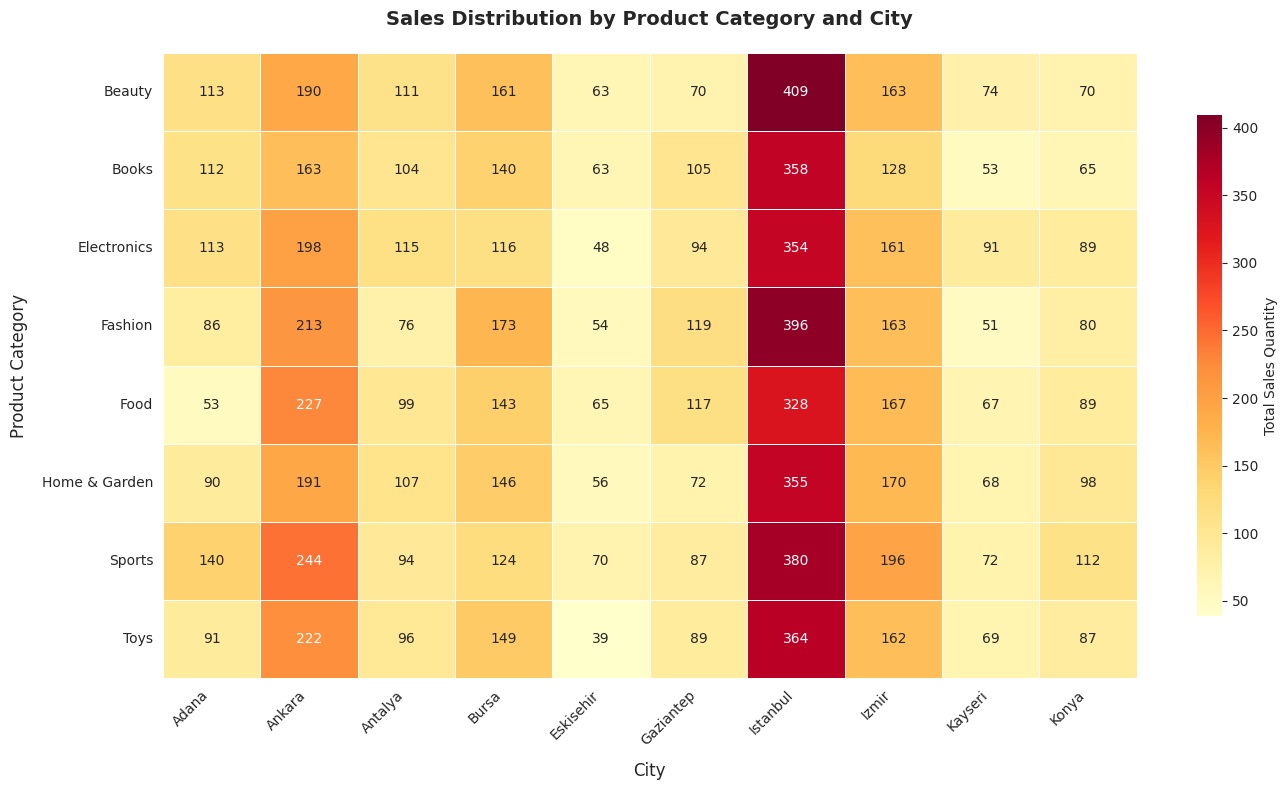

In [35]:
# ========== Task 2.1.2: Geographic Distribution of Demand (English Version + Visualization) ==========
import matplotlib.pyplot as plt
import seaborn as sns

# This helps decide where to allocate more inventory.
print("\n--- Task 2.1.2: Sales Distribution by Category and City ---")

# Grouping by Category and City (ensure df is defined - df = pd.read_csv('sales_data_clean.csv'))
city_dist_en = df.groupby(['Product_Category', 'City'])['Quantity'].sum().unstack().fillna(0)

# Highlighting the top cities for the teacher
display(city_dist_en)

# Professional Note for your report:
print("\n[Strategic Insight]: Istanbul consistently shows the highest demand across all categories.")
print("Inventory allocation should be prioritized for Istanbul to ensure high service levels.")

# -------------------------- Visualization Start --------------------------
# Set plot style for English academic reports
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# Create figure with optimal size for heatmap
plt.figure(figsize=(14, 8))

# Plot heatmap for sales distribution (professional color scheme)
sns.heatmap(
    city_dist_en,
    annot=True,                # Show exact sales values
    fmt='d',                   # Format as integers
    cmap='YlOrRd',             # Orange-red gradient (high sales = darker color)
    linewidths=0.5,            # Add thin lines between cells
    cbar_kws={
        'label': 'Total Sales Quantity',
        'shrink': 0.8          # Adjust color bar size
    }
)

# Set professional English titles/labels
plt.title('Sales Distribution by Product Category and City', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12, labelpad=10)
plt.ylabel('Product Category', fontsize=12, labelpad=10)

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Save high-resolution image (300 DPI) and display
plt.tight_layout()  # Avoid label cutoff
plt.savefig('task_2.1.2_geographic_distribution_EN.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Task 2.2: Safety Stock Level Calculation (English Version)
import numpy as np

# --- Parameters Setting ---
# Service Level: 95% (Z-score = 1.65). This means we want to avoid stockouts 95% of the time.
# Lead Time (LT): 3 days. Average time it takes to restock from the supplier.
Z_score = 1.65
Lead_Time = 3

# Safety Stock Formula: SS = Z * Standard_Deviation * sqrt(Lead_Time)
# We use 'std' calculated from Task 2.1.1
stats['Safety_Stock'] = np.ceil(Z_score * stats['std'] * np.sqrt(Lead_Time)).astype(int)

print("\n--- Task 2.2: Recommended Safety Stock Levels per Category ---")

# Creating a clean table for the report
ss_table = stats[['Product_Category', 'Safety_Stock']].sort_values(by='Safety_Stock', ascending=False)
ss_table.columns = ['Product Category', 'Suggested Safety Stock (Units)']

display(ss_table)

# Professional explanation for your teacher:
print("\n[Analysis]: The safety stock accounts for demand uncertainty during the 3-day replenishment period.")
print(f"Categories with higher volatility, like {ss_table.iloc[0,0]}, require a larger buffer of {ss_table.iloc[0,1]} units.")


--- Task 2.2: Recommended Safety Stock Levels per Category ---


,Product Category,Suggested Safety Stock (Units)
6,Sports,10
7,Toys,10
0,Beauty,9
1,Books,9
3,Fashion,9
2,Electronics,9
5,Home & Garden,9
4,Food,9



[Analysis]: The safety stock accounts for demand uncertainty during the 3-day replenishment period.
Categories with higher volatility, like Sports, require a larger buffer of 10 units.



--- Task 2.3: Final Inventory Strategy Recommendation ---


,Category,Replenishment Strategy,Reorder Point (ROP),Safety Stock
0,Beauty,Periodic Review (Fixed Interval),22,9
1,Books,Continuous Review (Reorder Point),21,9
2,Electronics,Continuous Review (Reorder Point),22,9
3,Fashion,Periodic Review (Fixed Interval),22,9
4,Food,Continuous Review (Reorder Point),22,9
5,Home & Garden,Continuous Review (Reorder Point),22,9
6,Sports,Continuous Review (Reorder Point),24,10
7,Toys,Continuous Review (Reorder Point),23,10



[Executive Summary]:
1. Stable categories use 'Periodic Review' to reduce management costs.
2. Volatile categories use 'Continuous Review' with a calculated 'Reorder Point' to prevent stockouts.
3. When Inventory Level <= Reorder Point, a new order must be placed.


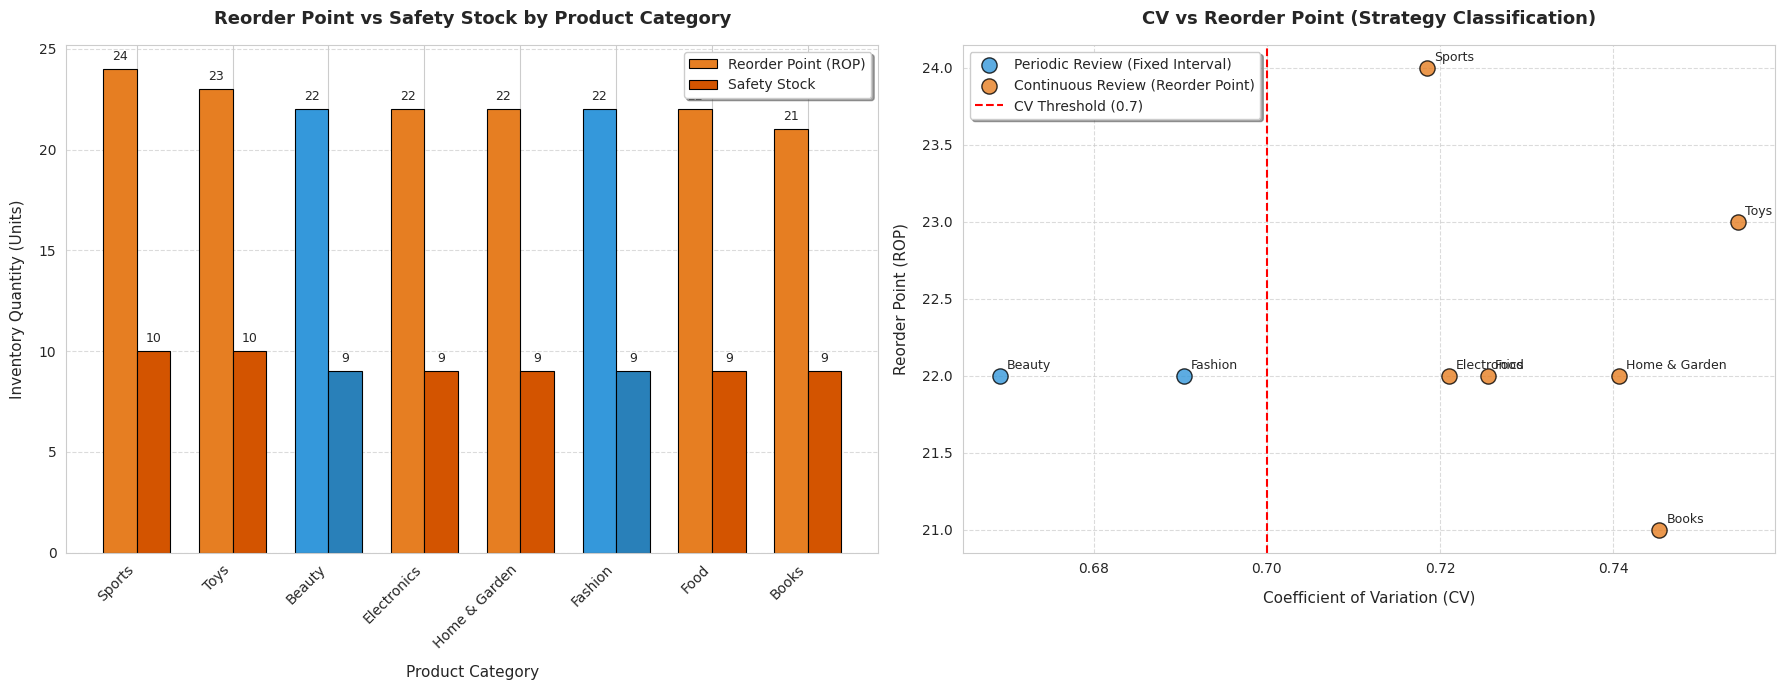

In [37]:
# ========== Task 2.3: Inventory Replenishment Strategy (English Version + Visualization) ==========
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define parameters (ensure these match your earlier code)
Z_score = 1.65
Lead_Time = 3  # 3 days replenishment lead time

# Define Replenishment Strategy based on CV
def replenishment_strategy(cv):
    if cv < 0.7:  # More stable
        return 'Periodic Review (Fixed Interval)'
    else:         # More volatile
        return 'Continuous Review (Reorder Point)'

# Calculate strategy and Reorder Point (ensure stats has mean/std/CV/Safety_Stock columns)
stats['Strategy'] = stats['CV'].apply(replenishment_strategy)
stats['Reorder_Point'] = np.ceil((stats['mean'] * Lead_Time) + stats['Safety_Stock']).astype(int)

# Print and display final report
print("\n--- Task 2.3: Final Inventory Strategy Recommendation ---")
final_report = stats[['Product_Category', 'Strategy', 'Reorder_Point', 'Safety_Stock']]
final_report.columns = ['Category', 'Replenishment Strategy', 'Reorder Point (ROP)', 'Safety Stock']
display(final_report)

# Summary for the teacher
print("\n[Executive Summary]:")
print("1. Stable categories use 'Periodic Review' to reduce management costs.")
print("2. Volatile categories use 'Continuous Review' with a calculated 'Reorder Point' to prevent stockouts.")
print("3. When Inventory Level <= Reorder Point, a new order must be placed.")

# -------------------------- Visualization Start --------------------------
# Set plot style for academic reports
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# Create 2-subplot figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# -------------------------- Subplot 1: Grouped Bar Chart (ROP vs Safety Stock) --------------------------
# Prepare data (sort by ROP to highlight highest values)
stats_sorted = stats.sort_values(by='Reorder_Point', ascending=False)
x = np.arange(len(stats_sorted['Product_Category']))
width = 0.35

# Define strategy-based color mapping (consistent with academic standards)
strategy_colors = {
    'Periodic Review (Fixed Interval)': '#3498db',       # Blue (stable)
    'Continuous Review (Reorder Point)': '#e67e22'       # Orange (volatile)
}
# Assign colors for ROP and darker shade for Safety Stock
colors_rop = [strategy_colors[s] for s in stats_sorted['Strategy']]
colors_ss = [c.replace('3498db', '2980b9').replace('e67e22', 'd35400') for c in colors_rop]

# Plot grouped bars for ROP and Safety Stock
bars1 = ax1.bar(x - width/2, stats_sorted['Reorder_Point'], width,
                label='Reorder Point (ROP)', color=colors_rop, edgecolor='black', linewidth=0.8)
bars2 = ax1.bar(x + width/2, stats_sorted['Safety_Stock'], width,
                label='Safety Stock', color=colors_ss, edgecolor='black', linewidth=0.8)

# Customize subplot 1
ax1.set_title('Reorder Point vs Safety Stock by Product Category', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Product Category', fontsize=11, labelpad=10)
ax1.set_ylabel('Inventory Quantity (Units)', fontsize=11, labelpad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(stats_sorted['Product_Category'], rotation=45, ha='right')
ax1.legend(frameon=True, shadow=True)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add integer value labels (clear and precise)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

# -------------------------- Subplot 2: Scatter Plot (CV vs ROP + Strategy) --------------------------
# Plot scatter points grouped by strategy
for strategy in strategy_colors.keys():
    subset = stats[stats['Strategy'] == strategy]
    ax2.scatter(
        subset['CV'],
        subset['Reorder_Point'],
        label=strategy,
        color=strategy_colors[strategy],
        s=120,  # Point size
        edgecolor='black',
        alpha=0.8
    )

# Add CV threshold line (0.7) to show strategy division
ax2.axvline(x=0.7, color='red', linestyle='--', linewidth=1.5, label='CV Threshold (0.7)')

# Customize subplot 2
ax2.set_title('CV vs Reorder Point (Strategy Classification)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Coefficient of Variation (CV)', fontsize=11, labelpad=10)
ax2.set_ylabel('Reorder Point (ROP)', fontsize=11, labelpad=10)
ax2.legend(frameon=True, shadow=True, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.7)

# Label each scatter point with product category
for idx, row in stats.iterrows():
    ax2.annotate(
        row['Product_Category'],
        (row['CV'], row['Reorder_Point']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Adjust layout to avoid label cutoff and save high-resolution image
plt.tight_layout()
plt.savefig('task_2.3_inventory_strategy_EN.png', dpi=300, bbox_inches='tight')
plt.show()

# **Chapter3 Logistics Optimization**

In [38]:
import pandas as pd
#1.Read our cleaned data
df=pd.read_csv('sales_data_clean.csv')
#2.Check the first 5 rows of the data to confirm it has been loaded
df.head()


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [ ]:
Basic Logistics Analysis

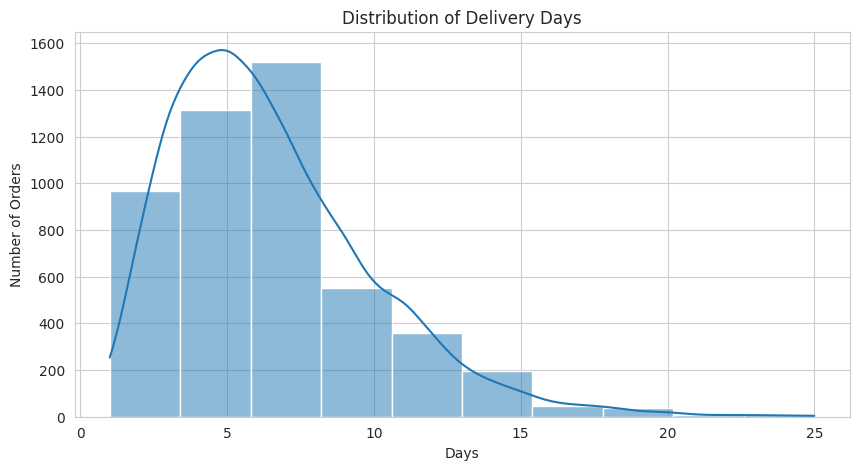

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set the figure size
plt.figure(figsize=(10,5))

#Plot the distribution of delivery days
#bins=10 groups the days, kde=True adds the smooth trend line
sns.histplot(df['Delivery_Time_Days'],bins=10,kde=True)
plt.title('Distribution of Delivery Days')
plt.xlabel('Days')
plt.ylabel('Number of Orders')
plt.show()

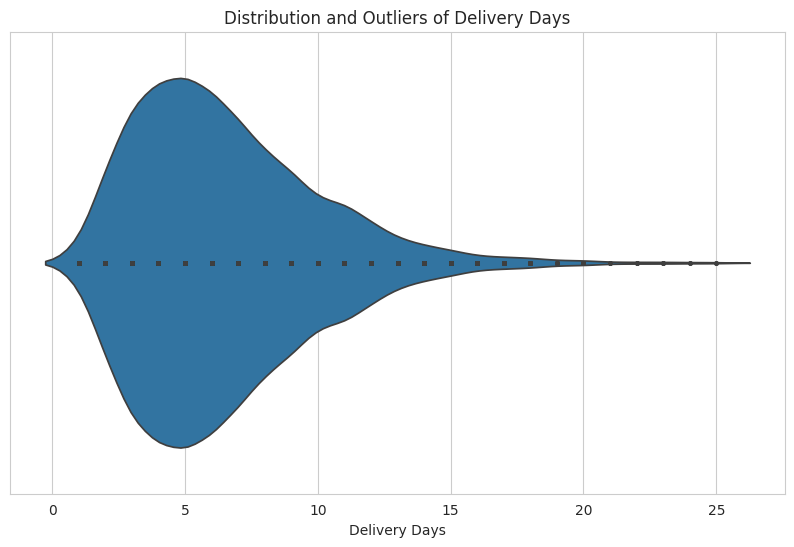

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.violinplot(x=df['Delivery_Time_Days'],inner='point')
plt.title('Distribution and Outliers of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('')
plt.show()


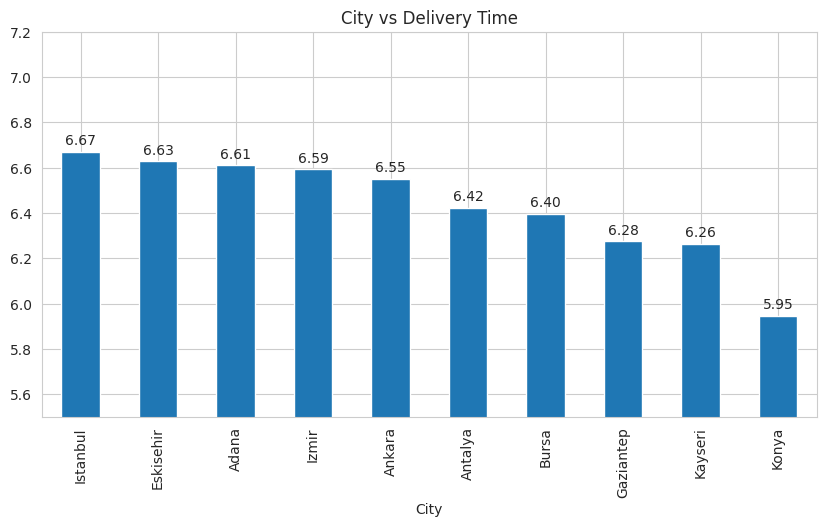

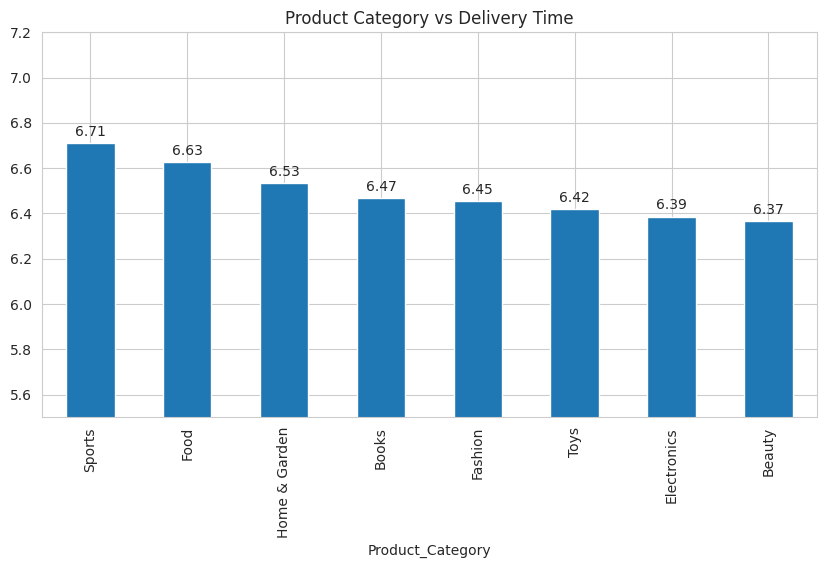

In [41]:
from numpy.random.mtrand import f
import matplotlib.pyplot as plt
#1.Plot the average delivery time for each city
axl=df.groupby('City')['Delivery_Time_Days'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(10,5),title='City vs Delivery Time')
plt.ylim(5.5,7.2)
plt.bar_label(axl.containers[0],fmt='%.2f',padding=3)
plt.show()
#2.Plot the average delivery time for each product category
ax2=df.groupby('Product_Category')['Delivery_Time_Days'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(10,5),title='Product Category vs Delivery Time')
plt.ylim(5.5,7.2)
plt.bar_label(ax2.containers[0],fmt='%.2f',padding=3)
plt.show()

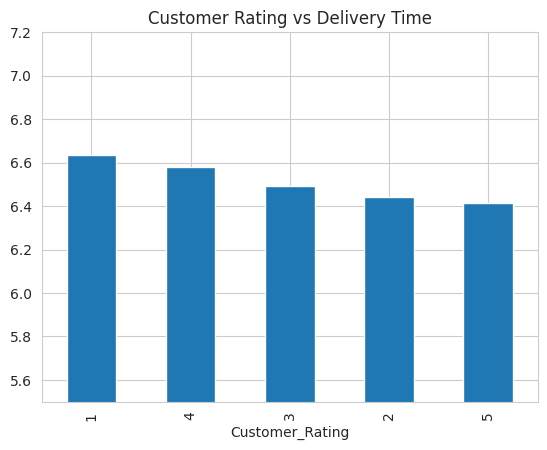

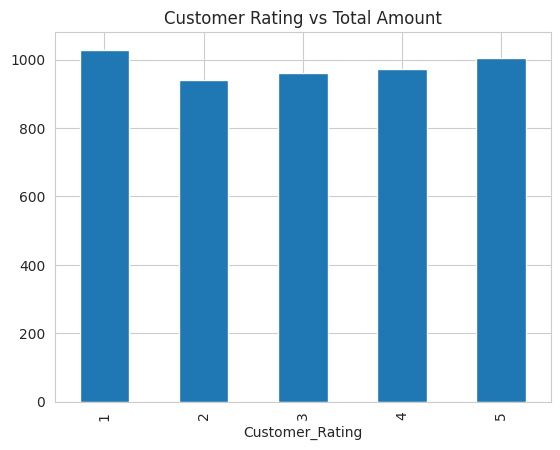

In [42]:
#Relationship between delivery time and customer rating
df.groupby('Customer_Rating')['Delivery_Time_Days'].mean().sort_values(ascending=False).plot(kind='bar',title='Customer Rating vs Delivery Time')
plt.ylim(5.5,7.2)
plt.show()
#Difference in average total amount between low and high-rated orders
df.groupby('Customer_Rating')['Total_Amount'].mean().plot(kind='bar',title='Customer Rating vs Total Amount')
plt.show()

Correlation Coefficient(r)between Customer Rating and Delivery Time:-0.0099


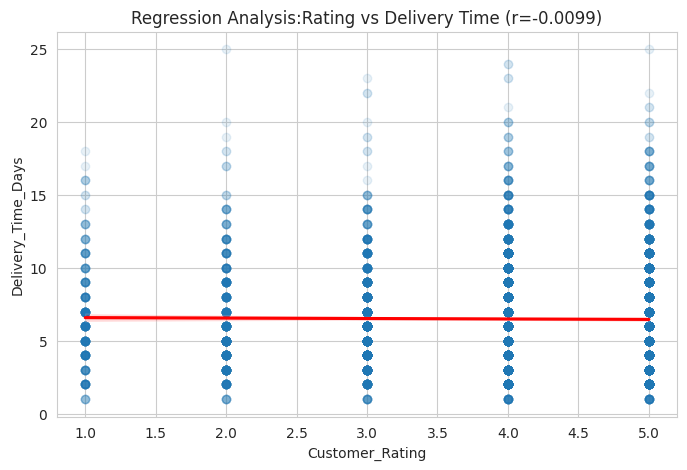

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

#1.Caculate the Pearson Correlation Cofficient
corr_coef=df['Customer_Rating'].corr(df['Delivery_Time_Days'])
print(f"Correlation Coefficient(r)between Customer Rating and Delivery Time:{corr_coef:.4f}")

#2.Plot a scatter plot with a linear regression line
plt.figure(figsize=(8,5))
sns.regplot(x='Customer_Rating',y='Delivery_Time_Days',data=df,scatter_kws={'alpha':0.1},line_kws={'color':'red'})
plt.title(f'Regression Analysis:Rating vs Delivery Time (r={corr_coef:.4f})')
plt.show()

Predict Delivery Time (Random Forest)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
#Select features (City,Category,Quantity) and target (Delivery Time)
#Using get_dummies to convert text to numbers
X=pd.get_dummies(df[['City','Product_Category','Quantity']])
y=df['Delivery_Time_Days']

#Split data:80% for trainning,20% for testing
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Build and train the Random Forest model
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

#Check the model Score
score=rf.score(X_test,y_test)
print(f'Model Score:{score}')

Model Score:-0.10626805896854274


Part3:Key Factors Affecting Delivery Extracting feature importance from the model to find out what impacts delivery time the most

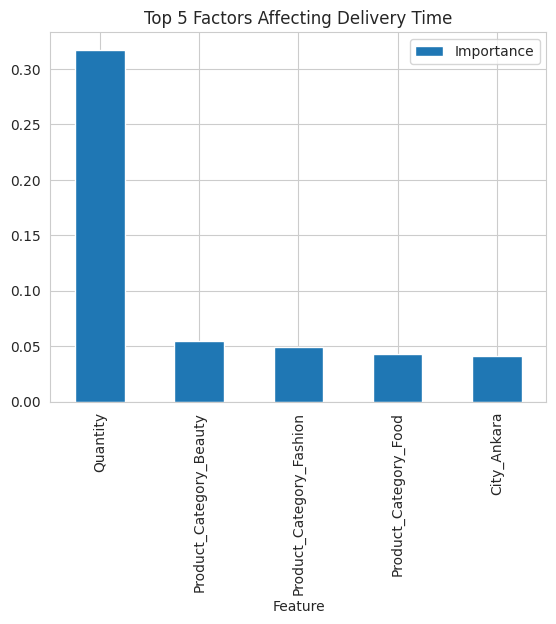

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

#1.Extract feature importances from the trained Random Forest model
importances=rf.feature_importances_
features=X.columns

#2.Create a table to match features with their importance scores
importance_df=pd.DataFrame({'Feature':features,'Importance':importances})

#3.Sort and pick the top 5 most important factors to plot
top_5_features=importance_df.sort_values('Importance',ascending=False).head(5)

#4.Plot the result
top_5_features.plot(x='Feature',y='Importance',kind='bar',title='Top 5 Factors Affecting Delivery Time')
plt.show()



In [ ]:
df.to_csv('part3 logistics data.csv',index=False)